# Notebook 07 : Analyse opérationnelle du modèle avec `transfer`

Objectif : transformer le modèle **avec le terme `transfer`** en analyse utile pour la gestion des lits et vérifier son comportement opérationnel sur la validation temporelle.

## Modèle utilisé dans ce notebook

| Paramètre | Valeur |
|-----------|--------|
| Modèle | Modèle principal issu du NB03 — avec `transfer` |
| Fichier modèle | `best_model.pkl` |
| Métadonnées | `model_metadata.json` |
| Texte NLP | `cleaned_complaint` |
| Seuil pré-alerte | Lu depuis `seuil_alerte` dans les métadonnées NB03 |
| Seuil fort | Lu depuis `seuil_fort` dans les métadonnées NB03 |
| Évaluation finale | Validation temporelle 2017–2019 |

> **Note méthodologique** : le seuil n'est pas recalculé dans ce notebook. Il est choisi dans NB03 sur la validation interne, puis appliqué ici une seule fois à la validation temporelle.


---
## 1. Imports

In [1]:
import gc
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix, hstack
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
)

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


---
## 2. Configuration

In [2]:
VALID_PERIOD = "2017 - 2019"
CHUNKSIZE = 25_000
TEXT_COL = "cleaned_complaint"
TEXT_MODEL_COL = TEXT_COL  # modèle opérationnel avec le terme transfer
PATTERN_TRANSFER = r"\btransfer\w*\b"

print("Configuration OK")

Configuration OK


In [3]:
#  Paramètres globaux 
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
TARGET = 'target'   # 1 = Hospitalisation, 0 = Retour domicile

#  Chemins projet 
def _racine_projet(reperes=("data", "results", "models", "notebooks")):
    """Racine = 1er dossier (courant ou parent) contenant un dossier repere."""
    for _p in (Path.cwd(), *Path.cwd().parents):
        if any((_p / _m).is_dir() for _m in reperes):
            return _p
    return Path.cwd()

ROOT_DIR   = _racine_projet()
BASE       = ROOT_DIR / "data"
OUT_DIR    = ROOT_DIR / "data" / "processed"
SPLIT_DIR  = OUT_DIR / "splits"
FIG_DIR    = ROOT_DIR / "figures"
RESULT_DIR = ROOT_DIR / "results"
TABLE_DIR  = RESULT_DIR / "tables"
MODEL_DIR  = ROOT_DIR / "models"

for _d in (OUT_DIR, SPLIT_DIR, FIG_DIR, RESULT_DIR, TABLE_DIR, MODEL_DIR):
    _d.mkdir(parents=True, exist_ok=True)

#  Données d'entrée
DATA_PATH = OUT_DIR / "cohort_nlp.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Cohorte introuvable : {DATA_PATH}\n"
        "Exécuter d'abord NB01 puis NB02."
    )

print("Paramètres globeaux OK")

Paramètres globeaux OK


In [4]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Fichier introuvable : {DATA_PATH}")

print("Fichier de données trouvé.")

Fichier de données trouvé.


---
## 3. Chargement des artefacts du modèle

In [5]:
artefacts = {
    "model": MODEL_DIR / "best_model.pkl",
    "tfidf": MODEL_DIR / "tfidf_vectorizer.pkl",
    "imputer": MODEL_DIR / "best_imputer.pkl",
    "scaler": MODEL_DIR / "best_scaler.pkl",
    "features": MODEL_DIR / "best_features.pkl",
    "metadata": MODEL_DIR / "model_metadata.json",
}

manquants = [nom for nom, path in artefacts.items() if not path.exists()]
if manquants:
    raise FileNotFoundError(
        "Artefacts manquants : " + ", ".join(manquants) +
        "\nExécuter d'abord le NB03 avec sauvegarde du modèle avec transfer."
    )

print("Artefacts du modèle avec transfer trouvés")

Artefacts du modèle avec transfer trouvés


In [6]:
model = joblib.load(artefacts["model"])
tfidf = joblib.load(artefacts["tfidf"])
imputer = joblib.load(artefacts["imputer"])
scaler = joblib.load(artefacts["scaler"])
features_num = joblib.load(artefacts["features"])

print("Artefacts chargés")
print("Type du modèle :", type(model).__name__)
print("Variables numériques attendues :", len(features_num))


Artefacts chargés
Type du modèle : MLPClassifier
Variables numériques attendues : 32


In [7]:
with open(artefacts["metadata"], "r", encoding="utf-8") as f:
    metadata = json.load(f)

version_finale = metadata.get("model_name", metadata.get("algo_opt", "modèle NB03"))
calibration_finale = bool(metadata.get("calibration_used_as_final", False))

seuil_alerte = float(
    metadata.get("seuil_alerte",
    metadata.get("seuil_alerte_final", 0.35))
)

seuil_fort = float(
    metadata.get("seuil_fort",
    metadata.get("seuil_fort_final", max(0.65, seuil_alerte + 0.05)))
)

print(f"Fichier métadonnées : {artefacts['metadata'].name}")
print(f"Modèle NB03 : {version_finale}")
print(f"Calibration retenue comme finale : {calibration_finale}")
print(f"Seuil pré-alerte : {seuil_alerte:.3f}")
print(f"Seuil fort       : {seuil_fort:.3f}")

Fichier métadonnées : model_metadata.json
Modèle NB03 : Modèle 3 — Variables structurées NB01 + NLP (MLP)
Calibration retenue comme finale : False
Seuil pré-alerte : 0.241
Seuil fort       : 0.650


In [8]:
# Diagnostic de cohérence NB03/NB07 : variables catégorielles
# -------------------------------------------------------------
# NB03 entraîne le modèle avec des dummies issues de gender et arrival_transport.
# cohort_nlp.csv conserve les colonnes brutes, mais ne contient pas ces dummies.
# NB07 doit donc les reconstruire avant de prédire.

diagnostic_input_path = OUT_DIR / "cohort_nlp.csv"
header = pd.read_csv(diagnostic_input_path, nrows=0, engine="python").columns.tolist()

dummies_attendues = [c for c in features_num if c.startswith(("gender_", "arrival_transport_"))]

print("Dummies attendues par le modèle :", dummies_attendues)
print("Dummies déjà présentes dans cohort_nlp.csv :", [c for c in dummies_attendues if c in header])
print("Dummies à reconstruire depuis les colonnes brutes :", [c for c in dummies_attendues if c not in header])
print("Colonnes brutes disponibles :", [c for c in ["gender", "arrival_transport"] if c in header])

if dummies_attendues and not any(c in header for c in dummies_attendues):
    if not {"gender", "arrival_transport"}.issubset(set(header)):
        raise ValueError(
            "Les dummies ne sont pas dans cohort_nlp.csv et les colonnes brutes "
            "gender / arrival_transport ne sont pas toutes disponibles."
        )
    print("OK, dummies construisent comme NB03.")


Dummies attendues par le modèle : ['gender_f', 'gender_m', 'arrival_transport_ambulance', 'arrival_transport_helicopter', 'arrival_transport_other', 'arrival_transport_unknown', 'arrival_transport_walk_in']
Dummies déjà présentes dans cohort_nlp.csv : []
Dummies à reconstruire depuis les colonnes brutes : ['gender_f', 'gender_m', 'arrival_transport_ambulance', 'arrival_transport_helicopter', 'arrival_transport_other', 'arrival_transport_unknown', 'arrival_transport_walk_in']
Colonnes brutes disponibles : ['gender', 'arrival_transport']
OK, dummies construisent comme NB03.


---
## 4. Préparation de la lecture mémoire

In [9]:
# Chargement du fichier produit par NB02.
# Ce notebook conserve le texte cleaned_complaint tel qu'il est utilisé par le modèle avec transfer.

input_path = OUT_DIR / "cohort_nlp.csv"

if not input_path.exists():
    raise FileNotFoundError(
        "Fichier cohort_nlp.csv introuvable. "
        "Exécuter d'abord NB01 puis NB02 pour générer la cohorte NLP."
    )

header = pd.read_csv(input_path, nrows=0, engine="python").columns.tolist()
header_set = set(header)

colonnes_base = [
    "subject_id", "stay_id", "intime", "anchor_year_group", TARGET,
    TEXT_COL, "age_ed", "anchor_age", "gender", "arrival_transport", "acuity",
]

colonnes_voulues = list(dict.fromkeys(
    [c for c in colonnes_base + list(features_num) if c in header_set]
))

# Le modèle avec transfer utilise directement cleaned_complaint.
if TEXT_MODEL_COL in header_set and TEXT_MODEL_COL not in colonnes_voulues:
    colonnes_voulues.append(TEXT_MODEL_COL)

obligatoires = ["subject_id", "anchor_year_group", TARGET, TEXT_COL]
manquantes = [c for c in obligatoires if c not in colonnes_voulues]
if manquantes:
    raise ValueError(f"Colonnes obligatoires absentes : {manquantes}")

print("Fichier utilisé :", input_path.name)
print("Colonnes lues :", len(colonnes_voulues))

Fichier utilisé : cohort_nlp.csv
Colonnes lues : 34


In [10]:
dtypes = {
    "heartrate": "float32",
    "sbp": "float32",
    "dbp": "float32",
    "o2sat": "float32",
    "resprate": "float32",
    "temperature": "float32",
    "age_ed": "float32",
    "anchor_age": "float32",
    "n_hosp_anterieures": "float32",
    "charlson_score_simplifie": "float32",
    "charlson_score": "float32",
    "acuity": "float32",
}

dtypes = {k: v for k, v in dtypes.items() if k in colonnes_voulues}
print("Dtypes numériques définis :", len(dtypes))

Dtypes numériques définis : 11


---
## 5. Fonctions propres et courtes

In [11]:
def nettoyer_cible(df):
    """Sécurise la cible et l'identifiant patient."""
    df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
    df["subject_id"] = pd.to_numeric(df["subject_id"], errors="coerce")
    df = df.dropna(subset=[TARGET, "subject_id"]).copy()
    df[TARGET] = df[TARGET].astype("int8")
    df["subject_id"] = df["subject_id"].astype("int64")
    return df

In [12]:
# comparaison entière via ayg_start 
def garder_validation_temporelle(df):
    """Garde uniquement la période de validation temporelle (comparaison entière robuste)."""
    df["anchor_year_group"] = df["anchor_year_group"].astype(str)
    if "ayg_start" not in df.columns:
        df["ayg_start"] = df["anchor_year_group"].str.extract(r"(\d{4})").astype(int)
    valid_year = int(VALID_PERIOD.split(" - ")[0].strip())
    return df[df["ayg_start"] >= valid_year].copy()

In [13]:
def preparer_texte_modele(df):
    """Prépare le texte utilisé par le modèle avec transfer.

    Le modèle opérationnel retenu conserve le motif de consultation nettoyé
    tel qu'il a été produit par NB02. Aucun retrait du terme transfer n'est réalisé ici.
    """
    df[TEXT_MODEL_COL] = df[TEXT_COL].fillna("").astype(str)
    return df

In [14]:
def _normaliser_modalite(s):
    """Normalise une modalité catégorielle comme dans NB03."""
    return (
        s.fillna("missing")
         .astype(str)
         .str.strip()
         .str.lower()
         .str.replace(r"[^a-z0-9]+", "_", regex=True)
         .str.strip("_")
         .replace("", "missing")
    )


def ajouter_dummies_nb03(df):
    """Reconstruit les dummies gender_* et arrival_transport_* attendues par NB03.

    Important : cohort_nlp.csv ne persiste pas ces colonnes. Les créer à zéro
    ferait perdre les variables catégorielles et dégraderait les performances.
    """
    df = df.copy()
    for col in ["gender", "arrival_transport"]:
        if col in df.columns:
            s = _normaliser_modalite(df[col])
            dummies = pd.get_dummies(s, prefix=col, dtype="int8")
            old_cols = [c for c in df.columns if c.startswith(f"{col}_")]
            if old_cols:
                df = df.drop(columns=old_cols)
            df = pd.concat([df, dummies], axis=1)
    return df


def completer_variables(df):
    """Aligne les variables sur best_features.pkl après reconstruction des dummies."""
    df = ajouter_dummies_nb03(df)

    dummies_attendues = [c for c in features_num if c.startswith(("gender_", "arrival_transport_"))]
    dummies_reconstruites = [c for c in dummies_attendues if c in df.columns]
    if dummies_attendues and len(dummies_reconstruites) == 0:
        raise ValueError(
            "Aucune dummy gender_/arrival_transport_ reconstruite. "
            "Vérifier la présence des colonnes brutes gender et arrival_transport."
        )

    for col in features_num:
        if col not in df.columns:
            df[col] = 0.0
    return df


In [15]:
def matrice_numerique(df):
    """Construit une matrice numérique alignée sur best_features.pkl."""
    cols = []
    for col in features_num:
        serie = pd.to_numeric(df[col], errors="coerce")
        cols.append(serie.to_numpy(dtype="float64", copy=False))
    return np.column_stack(cols).astype("float64", copy=False)


In [16]:
def predire_chunk(df):
    """Prépare un bloc et renvoie les prédictions."""
    df = nettoyer_cible(df)
    df = garder_validation_temporelle(df)
    if df.empty:
        return pd.DataFrame()

    df = preparer_texte_modele(df)
    df = completer_variables(df)

    X_num = matrice_numerique(df)
    X_num = imputer.transform(X_num)
    X_num = scaler.transform(X_num)

    X_txt = tfidf.transform(df[TEXT_MODEL_COL].fillna(""))
    X = hstack([csr_matrix(X_num), X_txt], format="csr")

    if type(model).__name__ == "MLPClassifier":
        X_pred = X.toarray()
    else:
        X_pred = X

    proba = model.predict_proba(X_pred)[:, 1]
    sortie = extraire_sortie(df, proba)

    del X_num, X_txt, X, X_pred
    gc.collect()
    return sortie


In [17]:
def extraire_sortie(df, proba):
    """Garde seulement les colonnes utiles pour l'analyse.

    Important : TEXT_COL et TEXT_MODEL_COL peuvent être identiques
    dans le modèle avec transfer. On déduplique donc les colonnes pour
    éviter que prediction_df contienne deux colonnes portant le même nom
    (ex. cleaned_complaint), ce qui provoque ensuite l'erreur
    "Grouper not 1-dimensional" lors de value_counts().
    """
    colonnes = [
        "subject_id", "stay_id", "intime", "anchor_year_group", TARGET,
        "age_ed", "anchor_age", "gender", "arrival_transport", "acuity",
        TEXT_COL, TEXT_MODEL_COL,
    ]

    # Conservation de l'ordre + suppression des doublons éventuels
    colonnes = list(dict.fromkeys([c for c in colonnes if c in df.columns]))

    out = df.loc[:, colonnes].copy()
    out = out.loc[:, ~out.columns.duplicated()].copy()
    out["proba_hospitalisation"] = proba
    return out

---
## 6. Prédiction par blocs

In [18]:
predictions = []

lecteur = pd.read_csv(
    input_path,
    usecols=colonnes_voulues,
    dtype=dtypes,
    chunksize=CHUNKSIZE,
    engine="python",
    on_bad_lines="skip",
)

for i, chunk in enumerate(lecteur, start=1):
    pred_chunk = predire_chunk(chunk)
    if not pred_chunk.empty:
        predictions.append(pred_chunk)
    if i % 10 == 0:
        print(f"{i} blocs traités")

if not predictions:
    raise ValueError("Aucune ligne de validation temporelle n'a été trouvée.")

prediction_df = pd.concat(predictions, ignore_index=True)
# Sécurité : suppression de colonnes dupliquées éventuelles après concaténation
prediction_df = prediction_df.loc[:, ~prediction_df.columns.duplicated()].copy()
del predictions
gc.collect()

print(f"Validation prédite : {len(prediction_df):,} séjours")

10 blocs traités
Validation prédite : 67,963 séjours


In [19]:
y_true = prediction_df[TARGET].astype(int).to_numpy()
y_proba = prediction_df["proba_hospitalisation"].astype("float32").to_numpy()

auc = roc_auc_score(y_true, y_proba)
ap = average_precision_score(y_true, y_proba)
brier = brier_score_loss(y_true, y_proba)

print(f"AUC validation temporelle : {auc:.4f}")
print(f"Average precision         : {ap:.4f}")
print(f"Brier score               : {brier:.4f}")

AUC validation temporelle : 0.8881
Average precision         : 0.8409
Brier score               : 0.1313


---
## 6b. Bootstrap: Intervalles de confiance à 95 %

Validation de la stabilité statistique du modèle final **avec `transfer`** sur la cohorte temporelle 2017–2019.

Le comparateur ESI est calculé sur la même cohorte temporelle lorsque la variable `acuity` est disponible.


In [20]:
from sklearn.metrics import confusion_matrix as _cm

def safe_div(num, den):
    return num / den if den > 0 else 0.0

def bootstrap_metrics(y_true_arr, y_proba_arr, seuil, n_boot=2000,
                       random_state=RANDOM_STATE):
    rng   = np.random.RandomState(random_state)
    idx_0 = np.where(y_true_arr == 0)[0]
    idx_1 = np.where(y_true_arr == 1)[0]
    aucs, baccs, ses, sps = [], [], [], []
    for _ in range(n_boot):
        boot_idx = np.concatenate([
            rng.choice(idx_0, size=len(idx_0), replace=True),
            rng.choice(idx_1, size=len(idx_1), replace=True),
        ])
        yt = y_true_arr[boot_idx]
        yp = y_proba_arr[boot_idx]
        yb = (yp >= seuil).astype(int)
        aucs.append(roc_auc_score(yt, yp))
        tn_, fp_, fn_, tp_ = _cm(yt, yb).ravel()
        se_ = safe_div(tp_, tp_ + fn_)
        sp_ = safe_div(tn_, tn_ + fp_)
        baccs.append((se_ + sp_) / 2)
        ses.append(se_)
        sps.append(sp_)
    return {
        "AUC_moy":       np.mean(aucs),
        "AUC_IC95_low":  np.percentile(aucs,   2.5),
        "AUC_IC95_up":   np.percentile(aucs,  97.5),
        "BACC_moy":      np.mean(baccs),
        "BACC_IC95_low": np.percentile(baccs,  2.5),
        "BACC_IC95_up":  np.percentile(baccs, 97.5),
        "Se_moy":        np.mean(ses),
        "Se_IC95_low":   np.percentile(ses,    2.5),
        "Se_IC95_up":    np.percentile(ses,   97.5),
        "Sp_moy":        np.mean(sps),
        "Sp_IC95_low":   np.percentile(sps,    2.5),
        "Sp_IC95_up":    np.percentile(sps,   97.5),
    }

print(f"Bootstrap modèle final avec transfer — {len(y_true):,} séjours, 2000 itérations...")
boot_model = bootstrap_metrics(y_true, y_proba, seuil=seuil_alerte, n_boot=2000)

# Comparateur ESI calculé sur la même validation temporelle.
# ESI 1 = plus urgent ; le score 6 - acuity donne un risque croissant.
if "acuity" in prediction_df.columns:
    acuity_num = pd.to_numeric(prediction_df["acuity"], errors="coerce")
    mask_esi = acuity_num.notna()
    if mask_esi.sum() > 0 and len(np.unique(y_true[mask_esi.to_numpy()])) == 2:
        score_esi = (6 - acuity_num[mask_esi]).to_numpy()
        auc_esi = roc_auc_score(y_true[mask_esi.to_numpy()], score_esi)
    else:
        auc_esi = np.nan
else:
    auc_esi = np.nan

overlap = (
    pd.notna(auc_esi)
    and boot_model["AUC_IC95_low"] <= auc_esi <= boot_model["AUC_IC95_up"]
)

print("Bootstrap terminé.")


Bootstrap modèle final avec transfer — 67,963 séjours, 2000 itérations...
Bootstrap terminé.


In [21]:
# Tableau de synthèse — 3 colonnes : Métrique | Résultat | IC 95%
df_boot = pd.DataFrame([
    {
        "Métrique": "Modèle",
        "Résultat": f"Avec transfer — {version_finale}",
        "IC 95%":   "—",
    },
    {
        "Métrique": "AUC",
        "Résultat": f"{boot_model['AUC_moy']:.4f}",
        "IC 95%":   f"[{boot_model['AUC_IC95_low']:.4f} – {boot_model['AUC_IC95_up']:.4f}]",
    },
    {
        "Métrique": "Balanced Accuracy",
        "Résultat": f"{boot_model['BACC_moy']:.4f}",
        "IC 95%":   f"[{boot_model['BACC_IC95_low']:.4f} – {boot_model['BACC_IC95_up']:.4f}]",
    },
    {
        "Métrique": "Sensibilité",
        "Résultat": f"{boot_model['Se_moy']:.4f}",
        "IC 95%":   f"[{boot_model['Se_IC95_low']:.4f} – {boot_model['Se_IC95_up']:.4f}]",
    },
    {
        "Métrique": "Spécificité",
        "Résultat": f"{boot_model['Sp_moy']:.4f}",
        "IC 95%":   f"[{boot_model['Sp_IC95_low']:.4f} – {boot_model['Sp_IC95_up']:.4f}]",
    },
    {
        "Métrique": "AUC ESI (référence)",
        "Résultat": "NA" if pd.isna(auc_esi) else f"{auc_esi:.4f}",
        "IC 95%":   "validation temporelle, même cohorte",
    },
])


In [22]:
print("\n=== BOOTSTRAP — IC 95% (2000 itérations stratifiées) ===")
display(df_boot.set_index("Métrique"))

print(f"\nIC AUC modèle : [{boot_model['AUC_IC95_low']:.4f} – {boot_model['AUC_IC95_up']:.4f}]")
if pd.notna(auc_esi):
    print(f"AUC ESI       : {auc_esi:.4f}")
    print(f"Chevauchement IC modèle / AUC ESI : {' OUI' if overlap else ' NON, donc,supériorité descriptive'}")
else:
    print("AUC ESI       : non calculable")

# Sauvegarde
boot_flat = {
    "modele":            f"avec_transfer_{version_finale}",
    "n_boot":            2000,
    "seuil":             seuil_alerte,
    **{k: float(v) for k, v in boot_model.items()},
    "ESI_AUC_ref":       None if pd.isna(auc_esi) else float(auc_esi),
    "IC_modele_overlap_ESI": bool(overlap),
}
pd.DataFrame([boot_flat]).to_csv(
    RESULT_DIR / "tab40_stats_bootstrap_avec.csv", index=False
)
print("\n ** tab40_stats_bootstrap_avec.csv sauvegardé")



=== BOOTSTRAP — IC 95% (2000 itérations stratifiées) ===


,Résultat,IC 95%
Métrique,,
Modèle,Avec transfer — Modèle 3 — Variables structuré...,—
AUC,0.8881,[0.8857 – 0.8906]
Balanced Accuracy,0.7886,[0.7858 – 0.7917]
Sensibilité,0.8911,[0.8873 – 0.8950]
Spécificité,0.6862,[0.6815 – 0.6906]
AUC ESI (référence),0.7063,"validation temporelle, même cohorte"



IC AUC modèle : [0.8857 – 0.8906]
AUC ESI       : 0.7063
Chevauchement IC modèle / AUC ESI :  NON, donc,supériorité descriptive

 ** tab40_stats_bootstrap_avec.csv sauvegardé


---
## 7. Métriques par seuil

In [23]:
def safe_div(a, b):
    return float(a / b) if b else np.nan


def metriques_seuil(y, p, seuil):
    pred = (p >= seuil).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    alertes = tp + fp
    admissions = tp + fn
    return {
        "Seuil": float(seuil),
        "Alertes": int(alertes),
        "Admissions": int(admissions),
        "VP": int(tp), "FP": int(fp), "FN": int(fn), "VN": int(tn),
        "Se": safe_div(tp, tp + fn),
        "Sp": safe_div(tn, tn + fp),
        "VPP": safe_div(tp, tp + fp),
        "VPN": safe_div(tn, tn + fn),
        "FNR": safe_div(fn, tp + fn),
        "FPR": safe_div(fp, fp + tn),
    }

In [24]:
seuils_a_tester = np.unique(np.r_[
    np.arange(0.05, 0.96, 0.05),
    seuil_alerte,
    0.50,
    seuil_fort,
])

analyse_seuils = pd.DataFrame([
    metriques_seuil(y_true, y_proba, s) for s in seuils_a_tester
]).sort_values("Seuil")

analyse_seuils.round(3).head()

,Seuil,Alertes,Admissions,VP,FP,FN,VN,Se,Sp,VPP,VPN,FNR,FPR
0,0.050,54253,26453,26143,28110,310,13400,0.988,0.323,0.482,0.977,0.012,0.677
1,0.100,47659,26453,25609,22050,844,19460,0.968,0.469,0.537,0.958,0.032,0.531
2,0.150,43036,26453,24927,18109,1526,23401,0.942,0.564,0.579,0.939,0.058,0.436
3,0.200,39173,26453,24168,15005,2285,26505,0.914,0.639,0.617,0.921,0.086,0.361
4,0.241,36597,26453,23572,13025,2881,28485,0.891,0.686,0.644,0.908,0.109,0.314


In [25]:
resume_seuils = pd.DataFrame([
    {"Seuil_type": "pré-alerte", **metriques_seuil(y_true, y_proba, seuil_alerte)},
    {"Seuil_type": "standard", **metriques_seuil(y_true, y_proba, 0.50)},
    {"Seuil_type": "fort", **metriques_seuil(y_true, y_proba, seuil_fort)},
])

resume_seuils.round(3)

,Seuil_type,Seuil,Alertes,Admissions,VP,FP,FN,VN,Se,Sp,VPP,VPN,FNR,FPR
0,pré-alerte,0.241,36597,26453,23572,13025,2881,28485,0.891,0.686,0.644,0.908,0.109,0.314
1,standard,0.500,23895,26453,18755,5140,7698,36370,0.709,0.876,0.785,0.825,0.291,0.124
2,fort,0.650,18156,26453,15358,2798,11095,38712,0.581,0.933,0.846,0.777,0.419,0.067


---
## 8. Indicateurs opérationnels standardisés

Les dates de MIMIC-IV sont anonymisées. Pour éviter d'interpréter ces dates comme de vrais jours calendaires, les indicateurs opérationnels sont exprimés **pour 100 passages aux urgences**.


In [26]:
# Les indicateurs par jour sont remplacés par des indicateurs pour 100 passages.
# Cette approche est plus robuste avec les dates anonymisées de MIMIC-IV.

n_passages = len(prediction_df)

print(f"Nombre total de passages analysés : {n_passages:,}")

Nombre total de passages analysés : 67,963


In [27]:
def ajouter_indicateurs_pour_100(table):
    """Ajoute des indicateurs standardisés pour 100 passages."""
    table = table.copy()

    for col in ["Alertes", "VP", "FP", "FN", "VN", "Admissions"]:
        if col in table.columns:
            table[f"{col}_pour_100_passages"] = table[col] / n_passages * 100

    return table


analyse_seuils = ajouter_indicateurs_pour_100(analyse_seuils)
resume_seuils = ajouter_indicateurs_pour_100(resume_seuils)

colonnes_resume = [
    "Seuil_type", "Seuil", "Se", "Sp", "VPP", "VPN",
    "Alertes_pour_100_passages",
    "VP_pour_100_passages",
    "FP_pour_100_passages",
    "FN_pour_100_passages",
]

resume_seuils[colonnes_resume].round(3)

,Seuil_type,Seuil,Se,Sp,VPP,VPN,Alertes_pour_100_passages,VP_pour_100_passages,FP_pour_100_passages,FN_pour_100_passages
0,pré-alerte,0.241,0.891,0.686,0.644,0.908,53.848,34.684,19.165,4.239
1,standard,0.500,0.709,0.876,0.785,0.825,35.159,27.596,7.563,11.327
2,fort,0.650,0.581,0.933,0.846,0.777,26.715,22.598,4.117,16.325


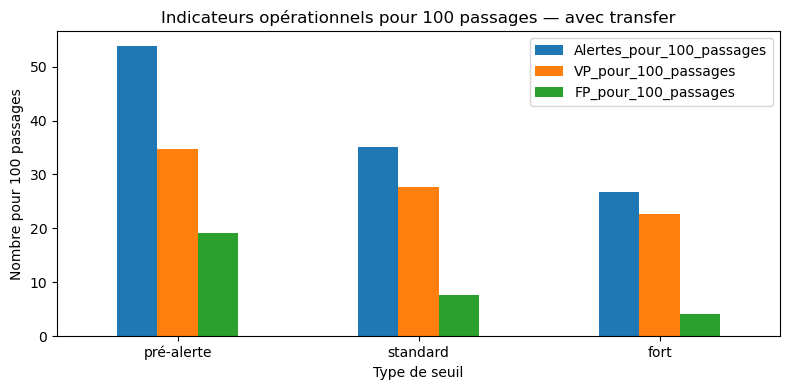

In [28]:
# Visualisation simple : nombre d'alertes, vrais positifs et faux positifs pour 100 passages.

plot_data = resume_seuils.set_index("Seuil_type")[[
    "Alertes_pour_100_passages",
    "VP_pour_100_passages",
    "FP_pour_100_passages",
]]

ax = plot_data.plot(kind="bar", figsize=(8, 4))
ax.set_title("Indicateurs opérationnels pour 100 passages — avec transfer")
ax.set_xlabel("Type de seuil")
ax.set_ylabel("Nombre pour 100 passages")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig41_indicateurs_100_passages_avec.png", dpi=300)
plt.show()


---
## 9. Classes de risque opérationnelles

In [29]:
seuil_intermediaire = 0.50
if not (seuil_alerte < seuil_intermediaire < seuil_fort):
    seuil_intermediaire = (seuil_alerte + seuil_fort) / 2

bins = [0, seuil_alerte, seuil_intermediaire, seuil_fort, 1.0]
labels = [
    "faible",
    "intermédiaire",
    "élevé",
    "très élevé",
]

prediction_df["classe_risque"] = pd.cut(
    prediction_df["proba_hospitalisation"],
    bins=bins,
    labels=labels,
    include_lowest=True,
)

print(f"Seuils des classes : {bins}")


Seuils des classes : [0, 0.241, 0.5, 0.65, 1.0]


In [30]:
classes_risque = prediction_df.groupby("classe_risque", observed=True).agg(
    n=(TARGET, "size"),
    hospitalisations=(TARGET, "sum"),
    proba_moyenne=("proba_hospitalisation", "mean"),
).reset_index()

classes_risque["taux_hospitalisation"] = (
    classes_risque["hospitalisations"] / classes_risque["n"]
)
classes_risque["part_population"] = classes_risque["n"] / len(prediction_df)

classes_risque.round(3)

,classe_risque,n,hospitalisations,proba_moyenne,taux_hospitalisation,part_population
0,faible,31366,2881,0.082,0.092,0.462
1,intermédiaire,12702,4817,0.363,0.379,0.187
2,élevé,5739,3397,0.574,0.592,0.084
3,très élevé,18156,15358,0.848,0.846,0.267


---
## 10. Stratégie top N pour 100 passages

Cette stratégie sélectionne les patients ayant les probabilités les plus élevées, en fixant un nombre d'alertes pour 100 passages. Elle remplace la logique "top N par jour", moins adaptée aux dates anonymisées de MIMIC-IV.


In [31]:
def strategie_top_n_pour_100(data, n_pour_100):
    """Évalue une stratégie qui alerte les n patients les plus à risque pour 100 passages."""
    n_selection = int(round(len(data) * n_pour_100 / 100))
    n_selection = max(1, min(n_selection, len(data)))

    seuil = data["proba_hospitalisation"].nlargest(n_selection).min()
    metriques = metriques_seuil(
        data[TARGET].to_numpy(),
        data["proba_hospitalisation"].to_numpy(),
        seuil,
    )

    metriques["Top_N_pour_100_passages"] = n_pour_100
    metriques["Seuil_implicite"] = float(seuil)
    return metriques

In [32]:
rows = []

for n in [5, 10, 15, 20, 30, 40, 50]:
    rows.append(strategie_top_n_pour_100(prediction_df, n))

topn_table = pd.DataFrame(rows)
topn_table = ajouter_indicateurs_pour_100(topn_table)

colonnes_topn = [
    "Top_N_pour_100_passages", "Seuil_implicite",
    "Se", "Sp", "VPP", "VPN",
    "Alertes_pour_100_passages",
    "VP_pour_100_passages",
    "FP_pour_100_passages",
    "FN_pour_100_passages",
]

topn_table[colonnes_topn].round(3)

,Top_N_pour_100_passages,Seuil_implicite,Se,Sp,VPP,VPN,Alertes_pour_100_passages,VP_pour_100_passages,FP_pour_100_passages,FN_pour_100_passages
0,5,0.957,0.125,0.998,0.976,0.642,5.000,4.879,0.121,34.044
1,10,0.900,0.246,0.993,0.956,0.674,10.000,9.558,0.441,29.365
2,15,0.837,0.356,0.982,0.925,0.705,14.999,13.871,1.129,25.052
3,20,0.762,0.460,0.965,0.894,0.737,20.001,17.886,2.114,21.036
4,30,0.590,0.634,0.913,0.823,0.797,30.000,24.693,5.307,14.230
5,40,0.423,0.766,0.833,0.745,0.848,40.000,29.813,10.186,9.109
6,50,0.288,0.863,0.731,0.672,0.893,50.001,33.592,16.409,5.331


---
## 11. Calibration en déciles

In [33]:
def table_calibration(y, p, n_bins=10):
    dfc = pd.DataFrame({"y": y, "p": p})
    dfc["decile"] = pd.qcut(dfc["p"], q=n_bins, duplicates="drop")
    tab = dfc.groupby("decile", observed=True).agg(
        n=("y", "size"),
        proba_moyenne=("p", "mean"),
        taux_observe=("y", "mean"),
    ).reset_index()
    tab["erreur_absolue"] = (tab["taux_observe"] - tab["proba_moyenne"]).abs()
    ece = (tab["n"] / tab["n"].sum() * tab["erreur_absolue"]).sum()
    return tab, float(ece)

calibration_deciles, ece = table_calibration(y_true, y_proba)
print(f"ECE : {ece:.4f}")
calibration_deciles.round(3)

ECE : 0.0091


,decile,n,proba_moyenne,taux_observe,erreur_absolue
0,"(-0.0009925700000000001, 0.0169]",6797,0.007,0.009,0.002
1,"(0.0169, 0.0493]",6796,0.032,0.036,0.004
2,"(0.0493, 0.101]",6796,0.073,0.081,0.008
3,"(0.101, 0.178]",6796,0.138,0.158,0.021
4,"(0.178, 0.288]",6797,0.230,0.249,0.020
5,"(0.288, 0.423]",6796,0.353,0.378,0.025
6,"(0.423, 0.59]",6796,0.504,0.512,0.008
7,"(0.59, 0.762]",6796,0.679,0.681,0.002
8,"(0.762, 0.9]",6796,0.835,0.833,0.002
9,"(0.9, 1.0]",6797,0.955,0.956,0.001


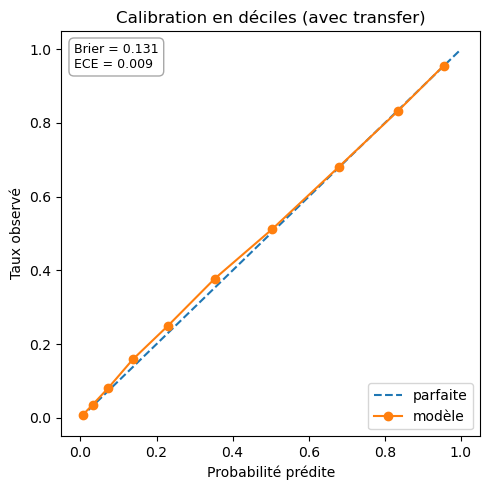

In [34]:
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], linestyle="--", label="parfaite")
plt.plot(
    calibration_deciles["proba_moyenne"],
    calibration_deciles["taux_observe"],
    marker="o",
    label="modèle",
)
plt.title("Calibration en déciles (avec transfer)")
plt.xlabel("Probabilité prédite")
plt.ylabel("Taux observé")
plt.legend()
# Métriques annotées sur la figure (ECE recalculé depuis le tableau de déciles).
_w = calibration_deciles['n'] if 'n' in calibration_deciles.columns else None
_ecart = (calibration_deciles['taux_observe'] - calibration_deciles['proba_moyenne']).abs()
_ece_fig = float((_ecart * _w).sum() / _w.sum()) if _w is not None else float(_ecart.mean())
_txt = f'ECE = {_ece_fig:.3f}'
try:
    _txt = f'Brier = {brier:.3f}\n' + _txt
except NameError:
    pass
plt.gca().text(0.03, 0.97, _txt, transform=plt.gca().transAxes, va='top', ha='left',
               fontsize=9, bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                                     alpha=0.85, edgecolor='#999999'))
plt.tight_layout()
plt.savefig(FIG_DIR / "fig42_calibration_deciles_avec.png", dpi=300)
plt.show()


---
## 12. Analyse par sous-groupes

In [35]:
def metriques_groupe(data, variable, seuil, min_n=100):
    rows = []
    for modalite, sub in data.groupby(variable, dropna=False):
        if len(sub) < min_n:
            continue
        y = sub[TARGET].astype(int).to_numpy()
        p = sub["proba_hospitalisation"].astype("float32").to_numpy()
        m = metriques_seuil(y, p, seuil)
        auc_g = roc_auc_score(y, p) if len(np.unique(y)) == 2 else np.nan
        rows.append({
            "variable": variable,
            "modalite": str(modalite),
            "n": len(sub),
            "taux_hospitalisation": y.mean(),
            "AUC": auc_g,
            "Se": m["Se"],
            "Sp": m["Sp"],
            "VPP": m["VPP"],
            "FN": m["FN"],
            "FP": m["FP"],
        })
    return pd.DataFrame(rows)

In [36]:
AGE_COL = 'age_ed' if 'age_ed' in prediction_df.columns else 'anchor_age'
prediction_df['age_groupe'] = pd.cut(
    pd.to_numeric(prediction_df.get(AGE_COL), errors='coerce'),
    bins=[0, 40, 65, 80, 200],
    labels=['<40', '40-64', '65-79', '>=80'],
    right=False,
)

variables_groupes = [
    c for c in ['age_groupe', 'gender', 'acuity']  # arrival_transport supprimé (v2)
    if c in prediction_df.columns
]

subgroup_metrics = pd.concat(
    [metriques_groupe(prediction_df, c, seuil_alerte) for c in variables_groupes],
    ignore_index=True,
)

#  Sauvegarde 
subgroup_metrics.round(3).to_csv(RESULT_DIR / 'tab41_fairness_subgroups_avec.csv', index=False)
print('tab41_fairness_subgroups_avec.csv sauvegardé')

# Analyse d'équité (Fairness) 
# Critère Se : |Se_groupe - Se_global| < 0.10
# Critère AUC : |AUC_groupe - AUC_global| < 0.05
# Exigence clinique : pas de sous-groupe systématiquement défavorisé.
# Référence globale calculée sur toute la validation, pas comme moyenne des sous-groupes.
m_global = metriques_seuil(y_true, y_proba, seuil_alerte)
Se_global  = float(m_global["Se"])
AUC_global = float(auc)

print('\n=== ANALYSE D\'ÉQUITÉ (Fairness Assessment) ===')
print(f'Se globale de référence  : {Se_global:.4f}')
print(f'AUC globale de référence : {AUC_global:.4f}')
print()

flags_equite = []
for _, row in subgroup_metrics.iterrows():
    se_ecart  = abs(row['Se']  - Se_global)  if not pd.isna(row['Se'])  else None
    auc_ecart = abs(row['AUC'] - AUC_global) if not pd.isna(row['AUC']) else None
    flag_se  = se_ecart  is not None and se_ecart  > 0.10
    flag_auc = auc_ecart is not None and auc_ecart > 0.05
    flag_str = ('⚠ Se' if flag_se else '  ') + (' ⚠ AUC' if flag_auc else '')
    if flag_se or flag_auc:
        flags_equite.append({
            'variable': row['variable'], 'modalite': row['modalite'],
            'n': row['n'], 'AUC': round(row['AUC'], 4) if not pd.isna(row['AUC']) else None,
            'Se': round(row['Se'], 4), 'Sp': round(row['Sp'], 4),
            'delta_Se': round(se_ecart, 4) if se_ecart else None,
            'delta_AUC': round(auc_ecart, 4) if auc_ecart else None,
            'flag': flag_str.strip()
        })
    print(f"{row['variable']:<20} {str(row['modalite']):<12} "
          f"n={row['n']:>6,}  AUC={row['AUC']:.3f}  Se={row['Se']:.3f}  {flag_str}")

if flags_equite:
    df_flags = pd.DataFrame(flags_equite)
    df_flags.to_csv(RESULT_DIR / 'tab42_fairness_flags_avec.csv', index=False)
    print(f'\n {len(flags_equite)} sous-groupe(s) avec écart significatif')
    print('tab42_fairness_flags_avec.csv sauvegardé')
else:
    print('\n Aucun écart significatif (|ΔSe|<0.10, |ΔAUC|<0.05) - équité satisfaisante')

display(subgroup_metrics.round(3))


tab41_fairness_subgroups_avec.csv sauvegardé

=== ANALYSE D'ÉQUITÉ (Fairness Assessment) ===
Se globale de référence  : 0.8911
AUC globale de référence : 0.8881

age_groupe           <40          n=27,440  AUC=0.865  Se=0.706  ⚠ Se
age_groupe           40-64        n=21,944  AUC=0.855  Se=0.892    
age_groupe           65-79        n=12,237  AUC=0.844  Se=0.957    
age_groupe           >=80         n= 6,342  AUC=0.829  Se=0.980     ⚠ AUC
gender               F            n=35,647  AUC=0.887  Se=0.868    
gender               M            n=32,316  AUC=0.888  Se=0.913    
acuity               1.0          n= 2,041  AUC=0.877  Se=0.980    
acuity               2.0          n=24,746  AUC=0.845  Se=0.961    
acuity               3.0          n=35,981  AUC=0.855  Se=0.783  ⚠ Se
acuity               4.0          n= 5,027  AUC=0.873  Se=0.125  ⚠ Se
acuity               5.0          n=   162  AUC=0.807  Se=0.000  ⚠ Se ⚠ AUC

 5 sous-groupe(s) avec écart significatif
tab42_fairness_flags_avec.c

,variable,modalite,n,taux_hospitalisation,AUC,Se,Sp,VPP,FN,FP
0,age_groupe,<40,27440,0.180,0.865,0.706,0.840,0.491,1452,3606
1,age_groupe,40-64,21944,0.428,0.855,0.892,0.588,0.619,1014,5163
2,age_groupe,65-79,12237,0.618,0.844,0.957,0.392,0.718,322,2843
3,age_groupe,>=80,6342,0.718,0.829,0.980,0.209,0.759,93,1413
4,gender,F,35647,0.365,0.887,0.868,0.721,0.641,1709,6330
5,gender,M,32316,0.416,0.888,0.913,0.645,0.647,1172,6695
6,acuity,1.0,2041,0.736,0.877,0.980,0.284,0.793,30,385
7,acuity,2.0,24746,0.597,0.845,0.961,0.349,0.686,576,6500
8,acuity,3.0,35981,0.281,0.855,0.783,0.764,0.563,2194,6121
9,acuity,4.0,5027,0.018,0.873,0.125,0.997,0.407,77,16


---
## 13. Faux négatifs

In [37]:
prediction_df["alerte_precoce"] = prediction_df["proba_hospitalisation"] >= seuil_alerte

faux_negatifs = prediction_df[
    (prediction_df[TARGET] == 1) &
    (~prediction_df["alerte_precoce"])
].copy()

print(f"Faux négatifs : {len(faux_negatifs):,}")
print(f"Part des hospitalisés manqués : {len(faux_negatifs) / max(1, y_true.sum()):.1%}")

Faux négatifs : 2,881
Part des hospitalisés manqués : 10.9%


In [38]:
# Analyse des motifs les plus fréquents parmi les faux négatifs
# Sécurité : si une colonne texte a été dupliquée par erreur, on force une Series 1D.
texte_fn = faux_negatifs.loc[:, TEXT_MODEL_COL]
if isinstance(texte_fn, pd.DataFrame):
    texte_fn = texte_fn.iloc[:, 0]

fn_motifs = (
    texte_fn
    .fillna("")
    .astype(str)
    .value_counts()
    .head(20)
    .rename_axis("motif")
    .reset_index(name="n")
)

fn_motifs

,motif,n
0,chest pain,101
1,abdominal pain,70
2,headache,62
3,rlq abdominal pain,54
4,flank pain,51
5,wound eval,46
6,chest pain dyspnea,45
7,low pain,44
8,pain,39
9,palpitation,33


---
## 14. Decision Curve Analysis

In [39]:
def net_benefit(y, p, pt):
    pred = (p >= pt).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    n = len(y)
    return (tp / n) - (fp / n) * (pt / (1 - pt))

thresholds = np.linspace(0.05, 0.95, 91)
prevalence = y_true.mean()

dca = pd.DataFrame({
    "threshold": thresholds,
    "model": [net_benefit(y_true, y_proba, t) for t in thresholds],
})

dca["alerter_tous"] = prevalence - (1 - prevalence) * dca["threshold"] / (1 - dca["threshold"])
dca["alerter_personne"] = 0

dca.head().round(4)

,threshold,model,alerter_tous,alerter_personne
0,0.05,0.3629,0.3571,0
1,0.06,0.3584,0.3502,0
2,0.07,0.3540,0.3433,0
3,0.08,0.3492,0.3361,0
4,0.09,0.3449,0.3288,0


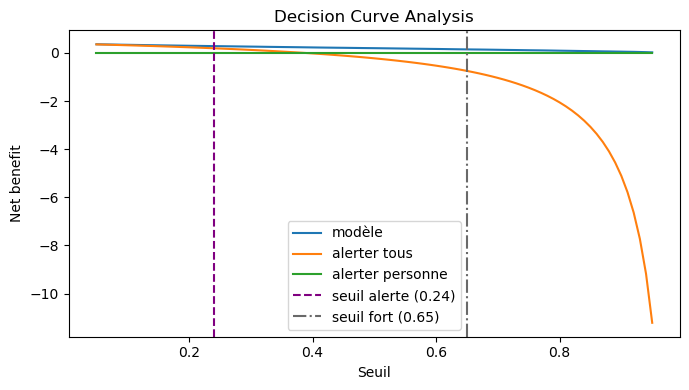

In [40]:
plt.figure(figsize=(7, 4))
plt.plot(dca["threshold"], dca["model"], label="modèle")
plt.plot(dca["threshold"], dca["alerter_tous"], label="alerter tous")
plt.plot(dca["threshold"], dca["alerter_personne"], label="alerter personne")
plt.axvline(seuil_alerte, color="purple", linestyle="--",
            label=f"seuil alerte ({seuil_alerte:.2f})")
plt.axvline(seuil_fort, color="dimgray", linestyle="-.",
            label=f"seuil fort ({seuil_fort:.2f})")
plt.title("Decision Curve Analysis")
plt.xlabel("Seuil")
plt.ylabel("Net benefit")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig43_decision_curve_avec.png", dpi=300)
plt.show()


---
## 15. Sauvegarde

In [41]:
prediction_df.to_csv(
    RESULT_DIR / "tab6_validation_predictions_op_avec.csv",
    index=False,
)

analyse_seuils.to_csv(TABLE_DIR / "tab7_analyse_seuils_op_avec.csv", index=False)
resume_seuils.to_csv(TABLE_DIR / "tab8_resume_seuils_op_avec.csv", index=False)
classes_risque.to_csv(TABLE_DIR / "tab9_classes_risque_op_avec.csv", index=False)
calibration_deciles.to_csv(TABLE_DIR / "tab4_calibration_deciles_avec_op.csv", index=False)
subgroup_metrics.to_csv(TABLE_DIR / "tab43_subgroup_metrics_avec.csv", index=False)
fn_motifs.to_csv(TABLE_DIR / "tab10_faux_negatifs_motifs_avec.csv", index=False)
dca.to_csv(TABLE_DIR / "tab44_decision_curve_avec.csv", index=False)

topn_table.to_csv(TABLE_DIR / "tab45_strategie_topN_avec.csv", index=False)

print("Sauvegarde terminée")

Sauvegarde terminée


---
## 16. Conformité TRIPOD+AI

Checklist de conformité aux recommandations TRIPOD+AI :
Collins GS, Moons KGM, Dhiman P, et al. TRIPOD+AI statement: updated guidance for reporting clinical prediction models that use regression or machine learning methods. BMJ. 2024;385:e078378.

In [42]:
# Checklist TRIPOD+AI 
# Cette étude suit les recommandations TRIPOD+AI (Collins et al., BMJ 2024)
# pour le signalement des modèles de prédiction basés sur l'IA.
# Référence : Collins GS, Moons KGM, Dhiman P, et al. TRIPOD+AI statement: updated guidance
# for reporting clinical prediction models that use regression or machine learning methods.
# BMJ. 2024;385:e078378.

tripod_items = [
    # TITRE ET RÉSUMÉ
    ('1a', 'Titre',             'Identification comme modèle de prédiction',        True,  'Titre du mémoire explicite'),
    ('1b', 'Résumé structuré',  'Résumé avec métriques principales et IC 95%',      True,  'Résumé contient AUC, Se, Sp, Brier, IC bootstrap'),
    # INTRODUCTION
    ('2',  'Contexte',          'Justification clinique et objectif du modèle',      True,  'Introduction chapitres 1-2'),
    ('3',  'Objectifs',         'Précision population cible et outcome prédit',       True,  'Hospitalisation depuis triage — adultes ≥18 ans'),
    # MÉTHODES
    ('4a', 'Source données',    'Description de la base MIMIC-IV ED',               True,  'NB01 — BIDMC, PhysioNet, conditions accès'),
    ('4b', 'Participants',      'Critères inclusion/exclusion + flowchart',          True,  'NB01 — flowchart 4 étapes, 383 919 séjours'),
    ('4c', 'Outcome',           'Définition précise de la variable cible',           True,  'ADMITTED=1, HOME=0, ambiguïtés exclues'),
    ('5',  'Prédicteurs',       'Variables utilisées et leur source',                True,  'NB03 — variables structurées + 1000 TF-IDF'),
    ('6',  'Taille échantillon','Justification de la taille',                       True,  '383 919 séjours, 188 127 patients uniques'),
    ('7',  'Valeurs manquantes','Stratégie d\'imputation documentée',               True,  'Médiane sur train uniquement — NB01'),
    ('8',  'Analyse statistique','Méthodes ML, optimisation, critère sélection',     True,  'Sélection clinique : Se≥90 % puis Sp@Se90 ; seuil choisi sur validation interne'),
    ('9',  'Split & validation','Séparation temporelle stricte 2017-2019',           True,  'ayg_start < 2017 / ≥ 2017, GroupShuffleSplit'),
    ('10', 'Performance',       'Métriques multiples avec IC 95%',                   True,  'AUC, Se, Sp, VPP, VPN, Brier, ECE + bootstrap'),
    ('11', 'Calibration',       'Évaluation et correction de la calibration',        True,  'Calibration retenue dynamiquement uniquement si le Brier validation interne s’améliore'),
    ('12', 'Interprétabilité', 'Méthodes d\'explication du modèle',                True,  'Interprétabilité adaptée au modèle final ; pas d’importance Gini si MLP'),
    ('13', 'Équité (Fairness)', 'Analyse par sous-groupes démographiques',           True,  'NB07 — âge, genre, acuity'),
    # RÉSULTATS
    ('14', 'Participants',      'Description de la cohorte (Table 1)',               True,  'NB06 — Table 1 format revue'),
    ('15', 'Performances',      'Métriques avec IC 95% sur validation temporelle',      True,  'NB07 — bootstrap 2000 itérations'),
    ('16', 'Calibration',       'Courbe de calibration + Brier + ECE',               True,  'NB04/NB07 — Brier, ECE et courbe de calibration'),
    ('17', 'Décision clinique', 'DCA — bénéfice net vs stratégies limites',          True,  'NB07 — Decision Curve Analysis'),
    # DISCUSSION
    ('18', 'Limites',           'Limites du modèle et des données documentées',      True,  'Mémoire Partie IV Chapitre 13'),
    ('19', 'Généralisabilité',  'Conditions de déploiement et recalibration',        True,  'Mémoire Chapitre 14 — validation prospective'),
    # NON CONFORMITÉS
    ('20', 'Données biologiques','Résultats biologiques non disponibles au triage',  False, 'LIMITE : NB non disponible → FN structurel'),
    ('21', 'Validation externe','Monocentrique — pas de validation multi-sites',    False, 'LIMITE : BIDMC uniquement, transposabilité limitée'),
]

df_tripod = pd.DataFrame(tripod_items,
    columns=['Item', 'Domaine', 'Critère', 'Conforme', 'Note'])

print('=== TRIPOD+AI CHECKLIST ===')
print(f'{df_tripod["Conforme"].sum()} / {len(df_tripod)} items conformes')
print()
for _, r in df_tripod.iterrows():
    status = '**' if r['Conforme'] else '## LIMITE'
    print(f"  {status}  [{r['Item']:>3}] {r['Domaine']:<22} {r['Note'][:60]}")

df_tripod.to_csv(RESULT_DIR / 'tab46_tripod_ai_checklist_avec.csv', index=False)
print('\n tab46_tripod_ai_checklist_avec.csv sauvegardé')

# Résumé des limites TRIPOD non conformes 
non_conformes = df_tripod[~df_tripod['Conforme']]
if len(non_conformes):
    print('\n** Non-conformités à documenter explicitement dans les limites du mémoire :')
    for _, r in non_conformes.iterrows():
        print(f"  [{r['Item']}] {r['Domaine']} — {r['Note']}")


=== TRIPOD+AI CHECKLIST ===
22 / 24 items conformes

  **  [ 1a] Titre                  Titre du mémoire explicite
  **  [ 1b] Résumé structuré       Résumé contient AUC, Se, Sp, Brier, IC bootstrap
  **  [  2] Contexte               Introduction chapitres 1-2
  **  [  3] Objectifs              Hospitalisation depuis triage — adultes ≥18 ans
  **  [ 4a] Source données         NB01 — BIDMC, PhysioNet, conditions accès
  **  [ 4b] Participants           NB01 — flowchart 4 étapes, 383 919 séjours
  **  [ 4c] Outcome                ADMITTED=1, HOME=0, ambiguïtés exclues
  **  [  5] Prédicteurs            NB03 — variables structurées + 1000 TF-IDF
  **  [  6] Taille échantillon     383 919 séjours, 188 127 patients uniques
  **  [  7] Valeurs manquantes     Médiane sur train uniquement — NB01
  **  [  8] Analyse statistique    Sélection clinique : Se≥90 % puis Sp@Se90 ; seuil choisi sur
  **  [  9] Split & validation     ayg_start < 2017 / ≥ 2017, GroupShuffleSplit
  **  [ 10] Performance  